# Notebook 02 — Poisson GLM and Gradient Boosting modeling

This notebook performs the modeling step of the ACT209 pricing frequency project.

The objective is to compare:

1. a constant frequency benchmark;
2. an unpenalized Poisson GLM;
3. a Gradient Boosting model with Poisson loss.

The models are trained to predict annual claim frequency. Their predictions are evaluated on the claim count scale using the exposure:

\[
\widehat{\mu}_i = E_i \widehat{\lambda}_i.
\]

The final calibration, lift and extreme prediction analyses are performed in:

```text
03_final_results.ipynb
```

## Actuarial modeling setup

For each policy \(i\), we denote:

\[
N_i = \text{observed claim count},
\]

\[
E_i = \text{exposure},
\]

\[
\lambda_i = \text{annual claim frequency}.
\]

The empirical claim frequency is:

\[
Y_i^{freq} = \frac{N_i}{E_i}.
\]

The models are fitted on empirical frequency:

\[
y_i = \frac{N_i}{E_i},
\]

using exposure as sample weight:

\[
w_i = E_i.
\]

Predicted annual frequency is denoted by \(\widehat{\lambda}_i\). The expected claim count is reconstructed as:

\[
\widehat{\mu}_i = E_i \widehat{\lambda}_i.
\]

The main evaluation metric is the mean Poisson deviance computed on the claim count scale.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [2]:
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "frequency_clean.csv"

OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data exists:", PROCESSED_PATH.exists())

Project root: c:\Users\hoxhi\Desktop\act209_pricing_frequency
Processed data exists: True


In [3]:
from src.data_preparation import (
    load_processed_data,
    get_feature_columns,
    split_numeric_categorical_features,
)

from src.preprocessing import (
    build_glm_preprocessor,
    build_tree_preprocessor,
)

from src.modeling import (
    build_poisson_glm_model,
    build_gradient_boosting_model,
    save_model,
)

from src.metrics import mean_poisson_deviance_from_frequency

## 1. Load processed data

We load the cleaned dataset generated by `01_data_exploration.ipynb`.

This dataset contains the empirical frequency target:

\[
\text{claim\_frequency}_i = \frac{\text{ClaimNb}_i}{\text{Exposure}_i}.
\]

In [4]:
df = load_processed_data(PROCESSED_PATH)

df.shape

(678013, 13)

In [5]:
df.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,claim_frequency
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,10.000000
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,1.298701
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,1.333333
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,11.111111
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,1.190476


In [6]:
df.columns.tolist()

['IDpol',
 'ClaimNb',
 'Exposure',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Area',
 'Density',
 'Region',
 'claim_frequency']

## 2. Define features, target and exposure

The target used for fitting is empirical claim frequency:

\[
y_i = \frac{N_i}{E_i}.
\]

The observed claim count \(N_i\) and the exposure \(E_i\) are kept separately for evaluation.

Exposure is not used as an ordinary explanatory variable. It is used as sample weight during model fitting and later to reconstruct expected claim counts.

In [7]:
claim_col = "ClaimNb"
exposure_col = "Exposure"
frequency_col = "claim_frequency"

feature_columns = get_feature_columns(df)
numeric_features, categorical_features = split_numeric_categorical_features(
    df,
    feature_columns,
)

X = df[feature_columns]
y_freq = df[frequency_col]
y_count = df[claim_col]
exposure = df[exposure_col]

feature_columns, numeric_features, categorical_features

(['VehPower',
  'VehAge',
  'DrivAge',
  'BonusMalus',
  'VehBrand',
  'VehGas',
  'Area',
  'Density',
  'Region'],
 ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density'],
 ['VehBrand', 'VehGas', 'Area', 'Region'])

In [8]:
print("Number of features:", len(feature_columns))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Number of features: 9
Numeric features: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
Categorical features: ['VehBrand', 'VehGas', 'Area', 'Region']


## 3. Train / validation / test split

The data are split into three sets:

- training set: model fitting;
- validation set: intermediate model comparison and diagnostics;
- test set: final out-of-sample evaluation.

The split is:

\[
60\% \text{ train}, \quad 20\% \text{ validation}, \quad 20\% \text{ test}.
\]

The validation set is not used for an exhaustive hyperparameter search. It is used as an intermediate control to compare the selected model specifications.

In [9]:
X_train_val, X_test, y_freq_train_val, y_freq_test, y_count_train_val, y_count_test, exposure_train_val, exposure_test = train_test_split(
    X,
    y_freq,
    y_count,
    exposure,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

X_train, X_valid, y_freq_train, y_freq_valid, y_count_train, y_count_valid, exposure_train, exposure_valid = train_test_split(
    X_train_val,
    y_freq_train_val,
    y_count_train_val,
    exposure_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "set": ["train", "validation", "test"],
    "n_policies": [len(X_train), len(X_valid), len(X_test)],
    "total_exposure": [
        exposure_train.sum(),
        exposure_valid.sum(),
        exposure_test.sum(),
    ],
    "observed_claims": [
        y_count_train.sum(),
        y_count_valid.sum(),
        y_count_test.sum(),
    ],
})

split_summary["observed_frequency"] = (
    split_summary["observed_claims"] / split_summary["total_exposure"]
)

split_summary

,set,n_policies,total_exposure,observed_claims,observed_frequency
0,train,406807,215069.758903,21571,0.100298
1,validation,135603,71805.263453,7290,0.101525
2,test,135603,71624.423106,7241,0.101097


In [10]:
split_summary.to_csv(
    OUTPUT_TABLES_DIR / "split_summary.csv",
    index=False,
)

## 4. Constant frequency benchmark

The first benchmark is a constant frequency model.

The predicted frequency is estimated on the training set only:

\[
\widehat{\lambda}_0 =
\frac{\sum_{i\in train} N_i}{\sum_{i\in train} E_i}.
\]

This benchmark is important because it gives a minimum reference level for predictive performance.

In [11]:
lambda_constant_train = y_count_train.sum() / exposure_train.sum()

lambda_pred_train_constant = np.full(shape=len(X_train), fill_value=lambda_constant_train)
lambda_pred_valid_constant = np.full(shape=len(X_valid), fill_value=lambda_constant_train)
lambda_pred_test_constant = np.full(shape=len(X_test), fill_value=lambda_constant_train)

deviance_train_constant = mean_poisson_deviance_from_frequency(
    y_count_train,
    exposure_train,
    lambda_pred_train_constant,
)

deviance_valid_constant = mean_poisson_deviance_from_frequency(
    y_count_valid,
    exposure_valid,
    lambda_pred_valid_constant,
)

deviance_test_constant = mean_poisson_deviance_from_frequency(
    y_count_test,
    exposure_test,
    lambda_pred_test_constant,
)

print("Constant benchmark frequency:", lambda_constant_train)
print("Constant benchmark train deviance:", deviance_train_constant)
print("Constant benchmark validation deviance:", deviance_valid_constant)
print("Constant benchmark test deviance:", deviance_test_constant)

Constant benchmark frequency: 0.10029768996830889
Constant benchmark train deviance: 0.33076490712809054
Constant benchmark validation deviance: 0.3317187802824953
Constant benchmark test deviance: 0.33142478381265916


## 5. Poisson GLM baseline

The Poisson GLM is the actuarial baseline model.

It is fitted as an unpenalized Poisson regression model:

\[
\alpha = 0.
\]

The model is trained on empirical claim frequency with exposure used as sample weight. This is consistent with evaluating the predictions on the claim count scale:

\[
\widehat{\mu}_i = E_i \widehat{\lambda}_i.
\]

The GLM uses:

- median imputation and standardization for numerical variables;
- most-frequent imputation and one-hot encoding with one dropped reference modality for categorical variables.

In [12]:
glm_preprocessor = build_glm_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

glm_model = build_poisson_glm_model(
    glm_preprocessor,
    alpha=0.0,
    max_iter=1000,
)

glm_model.fit(
    X_train,
    y_freq_train,
    model__sample_weight=exposure_train,
)

lambda_pred_train_glm = glm_model.predict(X_train)
lambda_pred_valid_glm = glm_model.predict(X_valid)
lambda_pred_test_glm = glm_model.predict(X_test)

deviance_train_glm = mean_poisson_deviance_from_frequency(
    y_count_train,
    exposure_train,
    lambda_pred_train_glm,
)

deviance_valid_glm = mean_poisson_deviance_from_frequency(
    y_count_valid,
    exposure_valid,
    lambda_pred_valid_glm,
)

deviance_test_glm = mean_poisson_deviance_from_frequency(
    y_count_test,
    exposure_test,
    lambda_pred_test_glm,
)

print("GLM train deviance:", deviance_train_glm)
print("GLM validation deviance:", deviance_valid_glm)
print("GLM test deviance:", deviance_test_glm)

GLM train deviance: 0.3201032349151858
GLM validation deviance: 0.3207957414397185
GLM test deviance: 0.3215902496211584


## 6. Poisson GLM coefficient interpretation

The Poisson GLM is directly interpretable through its coefficients.

With a log link, the model has the form:

\[
\log(\lambda_i) = \beta_0 + X_i^\top \beta.
\]

For a numerical variable \(X_j\), the multiplicative effect is:

\[
\exp(\beta_j).
\]

Because numerical variables are standardized in the preprocessing pipeline, the numerical coefficients are interpreted for a one-standard-deviation increase in the corresponding variable, all else being equal.

This section focuses on numerical coefficients only. Categorical variables are included in the model, but the main report interpretation focuses on numerical effects for clarity.

In [13]:
glm_estimator = glm_model.named_steps["model"]
glm_feature_names = glm_model.named_steps["preprocessor"].get_feature_names_out()

glm_coefficients_all = pd.DataFrame({
    "feature": glm_feature_names,
    "coefficient": glm_estimator.coef_,
})

glm_coefficients_all["multiplicative_effect"] = np.exp(
    glm_coefficients_all["coefficient"]
)

glm_coefficients_all["percentage_effect"] = (
    glm_coefficients_all["multiplicative_effect"] - 1.0
) * 100

glm_numeric_coefficients = glm_coefficients_all[
    glm_coefficients_all["feature"].isin(numeric_features)
].copy()

glm_numeric_coefficients["absolute_coefficient"] = (
    glm_numeric_coefficients["coefficient"].abs()
)

glm_numeric_coefficients = glm_numeric_coefficients.sort_values(
    by="absolute_coefficient",
    ascending=False,
)

glm_numeric_coefficients

,feature,coefficient,multiplicative_effect,percentage_effect,absolute_coefficient
3,BonusMalus,0.348296,1.416652,41.665212,0.348296
1,VehAge,-0.222863,0.800224,-19.977589,0.222863
2,DrivAge,0.092979,1.097439,9.743872,0.092979
0,VehPower,0.027806,1.028197,2.819662,0.027806
4,Density,0.016487,1.016623,1.662335,0.016487


In [14]:
glm_numeric_coefficients.to_csv(
    OUTPUT_TABLES_DIR / "glm_numeric_coefficients.csv",
    index=False,
)

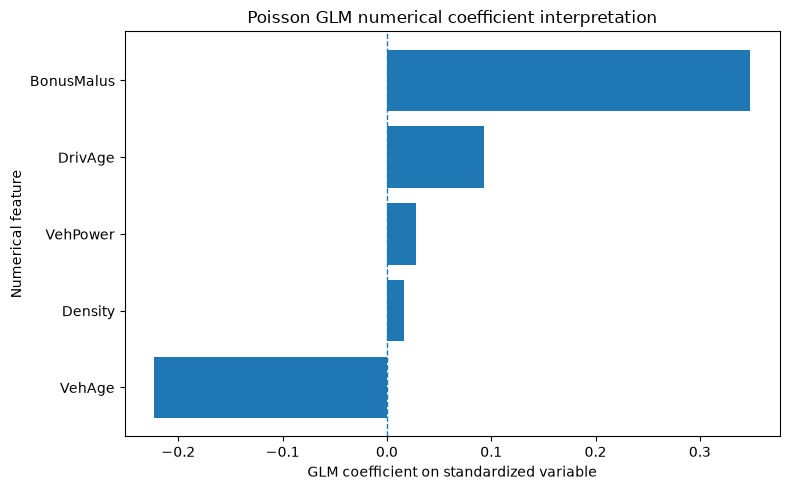

In [15]:
plot_data = glm_numeric_coefficients.sort_values(
    by="coefficient",
    ascending=True,
)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["feature"],
    plot_data["coefficient"],
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("GLM coefficient on standardized variable")
plt.ylabel("Numerical feature")
plt.title("Poisson GLM numerical coefficient interpretation")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "glm_numeric_coefficients.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 7. Gradient Boosting with Poisson loss

The Gradient Boosting model is used as the flexible machine learning model.

It is fitted with Poisson loss, which is coherent with non-negative claim frequency modeling. Compared with the GLM, Gradient Boosting can capture nonlinear effects and interactions, but its predictions are less directly interpretable.

The selected hyperparameters are moderate and intentionally simple:

- `learning_rate = 0.05`;
- `max_iter = 100`;
- `max_leaf_nodes = 31`;
- `min_samples_leaf = 100`;
- `l2_regularization = 0.0`.

These parameters were not selected through an exhaustive grid search. The validation set is used as an intermediate control of the selected specification.

In [16]:
gb_preprocessor = build_tree_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
)

gb_model = build_gradient_boosting_model(
    gb_preprocessor,
    learning_rate=0.05,
    max_iter=100,
    max_leaf_nodes=31,
    min_samples_leaf=100,
    l2_regularization=0.0,
    random_state=RANDOM_STATE,
)

gb_model.fit(
    X_train,
    y_freq_train,
    model__sample_weight=exposure_train,
)

lambda_pred_train_gb = gb_model.predict(X_train)
lambda_pred_valid_gb = gb_model.predict(X_valid)
lambda_pred_test_gb = gb_model.predict(X_test)

deviance_train_gb = mean_poisson_deviance_from_frequency(
    y_count_train,
    exposure_train,
    lambda_pred_train_gb,
)

deviance_valid_gb = mean_poisson_deviance_from_frequency(
    y_count_valid,
    exposure_valid,
    lambda_pred_valid_gb,
)

deviance_test_gb = mean_poisson_deviance_from_frequency(
    y_count_test,
    exposure_test,
    lambda_pred_test_gb,
)

print("GB train deviance:", deviance_train_gb)
print("GB validation deviance:", deviance_valid_gb)
print("GB test deviance:", deviance_test_gb)

GB train deviance: 0.29804818799758587
GB validation deviance: 0.30369848860652177
GB test deviance: 0.3057275783852223


## 8. Gradient Boosting permutation feature importance

Gradient Boosting is less directly interpretable than the Poisson GLM. To provide a simple interpretation, we compute permutation feature importance on the validation set.

For each explanatory variable, the values are randomly permuted and the resulting increase in validation Poisson deviance is measured.

A larger increase means that the fitted Gradient Boosting model relies more strongly on that variable for prediction.

This analysis measures predictive contribution, not causal effect.

In [17]:
n_fi = min(50000, len(X_valid))

X_valid_fi = X_valid.sample(
    n=n_fi,
    random_state=RANDOM_STATE,
)

y_freq_valid_fi = y_freq_valid.loc[X_valid_fi.index]
y_count_valid_fi = y_count_valid.loc[X_valid_fi.index]
exposure_valid_fi = exposure_valid.loc[X_valid_fi.index]

print("Feature importance sample size:", len(X_valid_fi))

Feature importance sample size: 50000


In [18]:
def gb_validation_scorer(estimator, X, y):
    """
    Custom scorer for permutation importance.

    sklearn expects a score to be maximized. Since lower Poisson deviance is
    better, this scorer returns the negative Poisson deviance.

    The score is computed on the claim count scale:

        mu_hat_i = exposure_i * lambda_hat_i.
    """
    index = X.index

    predicted_frequency = estimator.predict(X)

    deviance = mean_poisson_deviance_from_frequency(
        y_count=y_count_valid_fi.loc[index],
        exposure=exposure_valid_fi.loc[index],
        predicted_frequency=predicted_frequency,
    )

    return -deviance

In [19]:
permutation_result = permutation_importance(
    estimator=gb_model,
    X=X_valid_fi,
    y=y_freq_valid_fi,
    scoring=gb_validation_scorer,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [20]:
gb_feature_importance = pd.DataFrame({
    "feature": X_valid_fi.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
})

gb_feature_importance = gb_feature_importance.sort_values(
    by="importance_mean",
    ascending=False,
)

gb_feature_importance

,feature,importance_mean,importance_std
1,VehAge,0.022781,0.000575
3,BonusMalus,0.022542,0.000605
4,VehBrand,0.010009,0.000534
2,DrivAge,0.004970,0.000364
5,VehGas,0.004031,0.000331
0,VehPower,0.003590,0.000350
7,Density,0.001305,0.000139
8,Region,0.000674,0.000148
6,Area,0.000047,0.000018


In [21]:
gb_feature_importance.to_csv(
    OUTPUT_TABLES_DIR / "gb_feature_importance.csv",
    index=False,
)

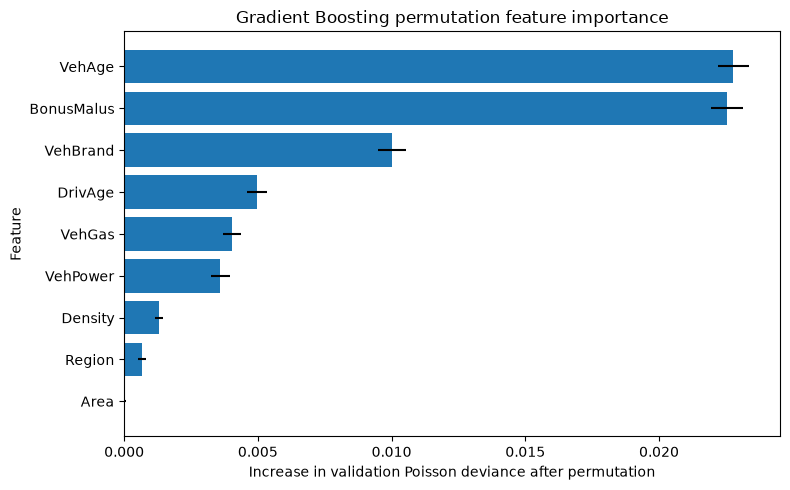

In [22]:
top_features = gb_feature_importance.sort_values(
    by="importance_mean",
    ascending=True,
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
)
plt.xlabel("Increase in validation Poisson deviance after permutation")
plt.ylabel("Feature")
plt.title("Gradient Boosting permutation feature importance")
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES_DIR / "gb_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Model performance comparison

We compare the constant benchmark, the Poisson GLM and the Gradient Boosting model using mean Poisson deviance.

Poisson deviance is a loss: lower values indicate better predictive performance.

The train-validation-test comparison also provides a simple diagnostic of overfitting.

In [23]:
performance_table = pd.DataFrame([
    {
        "model": "Constant benchmark",
        "train_poisson_deviance": deviance_train_constant,
        "validation_poisson_deviance": deviance_valid_constant,
        "test_poisson_deviance": deviance_test_constant,
        "validation_train_gap": deviance_valid_constant - deviance_train_constant,
        "test_train_gap": deviance_test_constant - deviance_train_constant,
    },
    {
        "model": "Poisson GLM",
        "train_poisson_deviance": deviance_train_glm,
        "validation_poisson_deviance": deviance_valid_glm,
        "test_poisson_deviance": deviance_test_glm,
        "validation_train_gap": deviance_valid_glm - deviance_train_glm,
        "test_train_gap": deviance_test_glm - deviance_train_glm,
    },
    {
        "model": "Gradient Boosting",
        "train_poisson_deviance": deviance_train_gb,
        "validation_poisson_deviance": deviance_valid_gb,
        "test_poisson_deviance": deviance_test_gb,
        "validation_train_gap": deviance_valid_gb - deviance_train_gb,
        "test_train_gap": deviance_test_gb - deviance_train_gb,
    },
])

performance_table

,model,train_poisson_deviance,validation_poisson_deviance,test_poisson_deviance,validation_train_gap,test_train_gap
0,Constant benchmark,0.330765,0.331719,0.331425,0.000954,0.000660
1,Poisson GLM,0.320103,0.320796,0.321590,0.000693,0.001487
2,Gradient Boosting,0.298048,0.303698,0.305728,0.005650,0.007679


In [24]:
performance_table.to_csv(
    OUTPUT_TABLES_DIR / "model_performance.csv",
    index=False,
)

## 10. Save models and test predictions

The fitted GLM and Gradient Boosting pipelines are saved for reproducibility.

We also save the test-set predictions. These predictions are used in `03_final_results.ipynb` for calibration, lift and predicted-frequency stability analyses.

In [25]:
save_model(
    glm_model,
    OUTPUT_MODELS_DIR / "glm_poisson.pkl",
)

save_model(
    gb_model,
    OUTPUT_MODELS_DIR / "gb_poisson.pkl",
)

list(OUTPUT_MODELS_DIR.glob("*.pkl"))

[WindowsPath('c:/Users/hoxhi/Desktop/act209_pricing_frequency/outputs/models/gb_poisson.pkl'),
 WindowsPath('c:/Users/hoxhi/Desktop/act209_pricing_frequency/outputs/models/glm_poisson.pkl')]

In [26]:
test_predictions = X_test.copy()

test_predictions["ClaimNb"] = y_count_test
test_predictions["Exposure"] = exposure_test
test_predictions["claim_frequency"] = y_freq_test

test_predictions["lambda_constant"] = lambda_pred_test_constant
test_predictions["lambda_glm"] = lambda_pred_test_glm
test_predictions["lambda_gb"] = lambda_pred_test_gb

test_predictions["mu_constant"] = (
    test_predictions["Exposure"] * test_predictions["lambda_constant"]
)

test_predictions["mu_glm"] = (
    test_predictions["Exposure"] * test_predictions["lambda_glm"]
)

test_predictions["mu_gb"] = (
    test_predictions["Exposure"] * test_predictions["lambda_gb"]
)

test_predictions.head()

,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimNb,Exposure,claim_frequency,lambda_constant,lambda_glm,lambda_gb,mu_constant,mu_glm,mu_gb
261354,7,18,36,95,B1,Regular,D,1054,Centre,0,0.43,0.0,0.100298,0.147365,0.122336,0.043128,0.063367,0.052604
448143,7,17,80,95,B2,Regular,D,598,Basse-Normandie,0,0.10,0.0,0.100298,0.172960,0.145429,0.010030,0.017296,0.014543
188618,7,3,36,76,B6,Regular,E,4172,Rhone-Alpes,0,0.33,0.0,0.100298,0.180966,0.143599,0.033098,0.059719,0.047388
12952,5,4,73,52,B13,Diesel,A,15,Centre,0,0.56,0.0,0.100298,0.097739,0.110630,0.056167,0.054734,0.061953
425028,8,0,37,50,B11,Diesel,E,3021,Bretagne,0,0.27,0.0,0.100298,0.114937,0.091076,0.027080,0.031033,0.024590


In [27]:
test_predictions.to_csv(
    OUTPUT_TABLES_DIR / "test_predictions.csv",
    index=False,
)

In [28]:
expected_outputs = [
    OUTPUT_TABLES_DIR / "split_summary.csv",
    OUTPUT_TABLES_DIR / "glm_numeric_coefficients.csv",
    OUTPUT_TABLES_DIR / "gb_feature_importance.csv",
    OUTPUT_TABLES_DIR / "model_performance.csv",
    OUTPUT_TABLES_DIR / "test_predictions.csv",
    OUTPUT_MODELS_DIR / "glm_poisson.pkl",
    OUTPUT_MODELS_DIR / "gb_poisson.pkl",
    OUTPUT_FIGURES_DIR / "glm_numeric_coefficients.png",
    OUTPUT_FIGURES_DIR / "gb_feature_importance.png",
]

output_check = pd.DataFrame({
    "file": [str(path.relative_to(PROJECT_ROOT)) for path in expected_outputs],
    "exists": [path.exists() for path in expected_outputs],
})

output_check

,file,exists
0,outputs\tables\split_summary.csv,True
1,outputs\tables\glm_numeric_coefficients.csv,True
2,outputs\tables\gb_feature_importance.csv,True
3,outputs\tables\model_performance.csv,True
4,outputs\tables\test_predictions.csv,True
5,outputs\models\glm_poisson.pkl,True
6,outputs\models\gb_poisson.pkl,True
7,outputs\figures\glm_numeric_coefficients.png,True
8,outputs\figures\gb_feature_importance.png,True


# Final conclusion of Notebook 02

The modeling step is complete.

Three models were fitted and evaluated:

1. a constant frequency benchmark;
2. an unpenalized Poisson GLM;
3. a Gradient Boosting model with Poisson loss.

The Poisson GLM provides an interpretable actuarial baseline. Its numerical coefficients can be interpreted through multiplicative effects on the predicted claim frequency, because the model uses a log link.

The Gradient Boosting model provides a more flexible predictive model. It may capture nonlinear effects and interactions that are not directly represented in the GLM. Its interpretation is therefore based on permutation feature importance rather than direct coefficients.

The models were compared using train, validation and test Poisson deviance. The test-set predictions were saved for the final analysis notebook, where calibration, lift and prediction stability are studied.